19:44:02 - cmdstanpy - INFO - Chain [1] start processing


Total days : 2313
Train size : 1850
Test size  : 463
Train: 2019-09-02 → 2024-09-24
Test:  2024-09-25 → 2025-12-31


19:44:03 - cmdstanpy - INFO - Chain [1] done processing


Model trained successfully
Rolling windows evaluated : 66
Total days evaluated      : 462
------------------------------
PROPHET EVALUATION RESULTS
------------------------------
RMSE: 1884.51 installs
MAE:  1474.03 installs
MAPE: 5.18%
------------------------------
Model metadata saved to prophet_model_meta.json


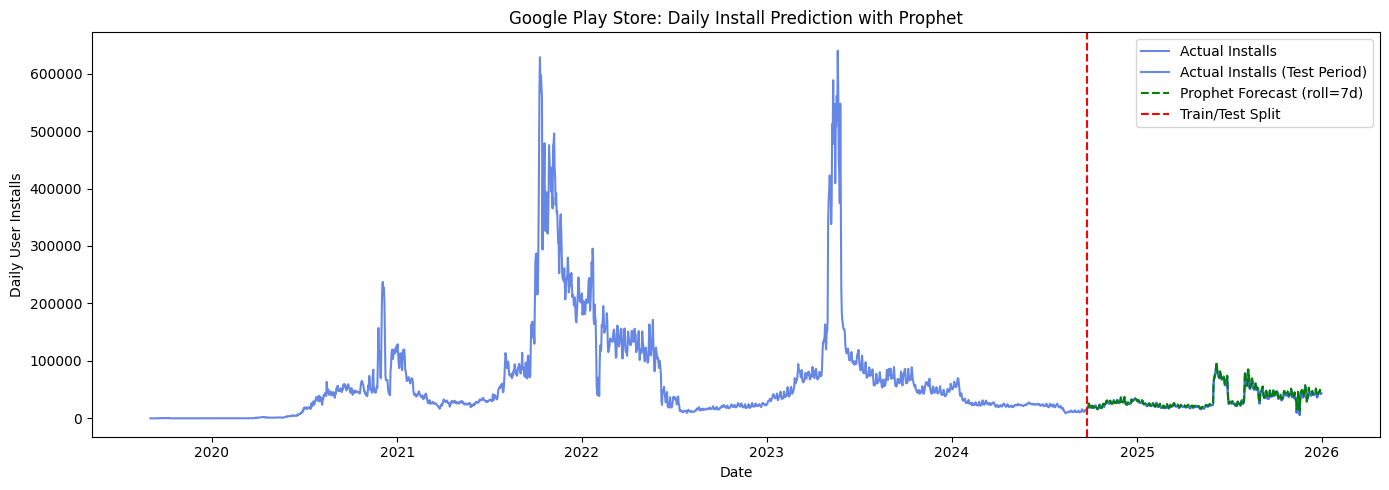

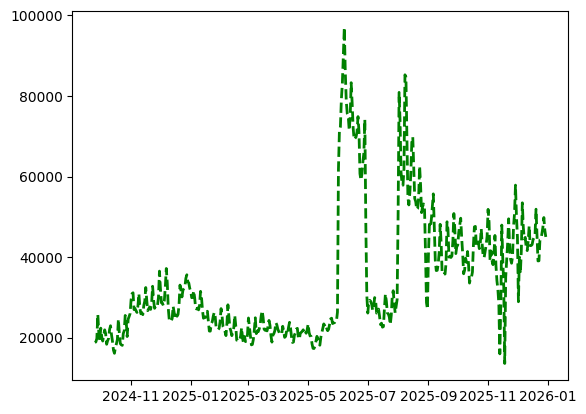

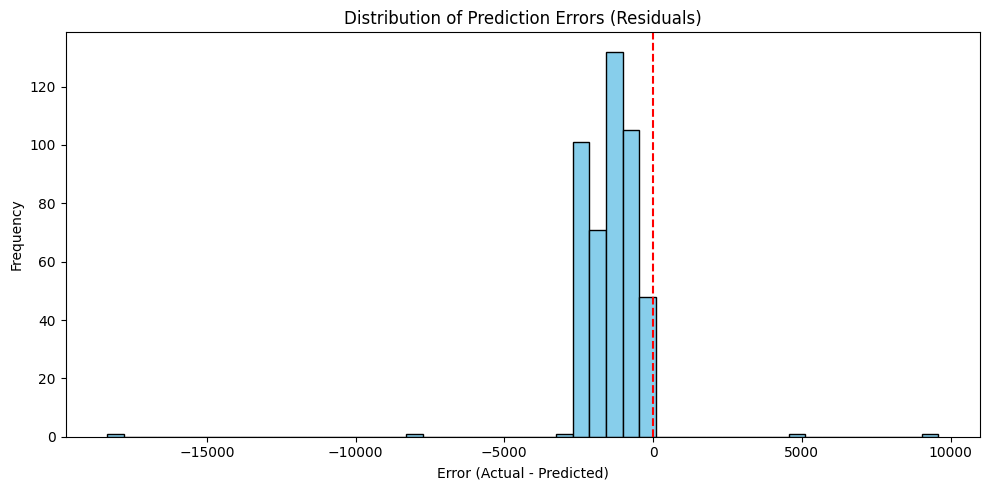

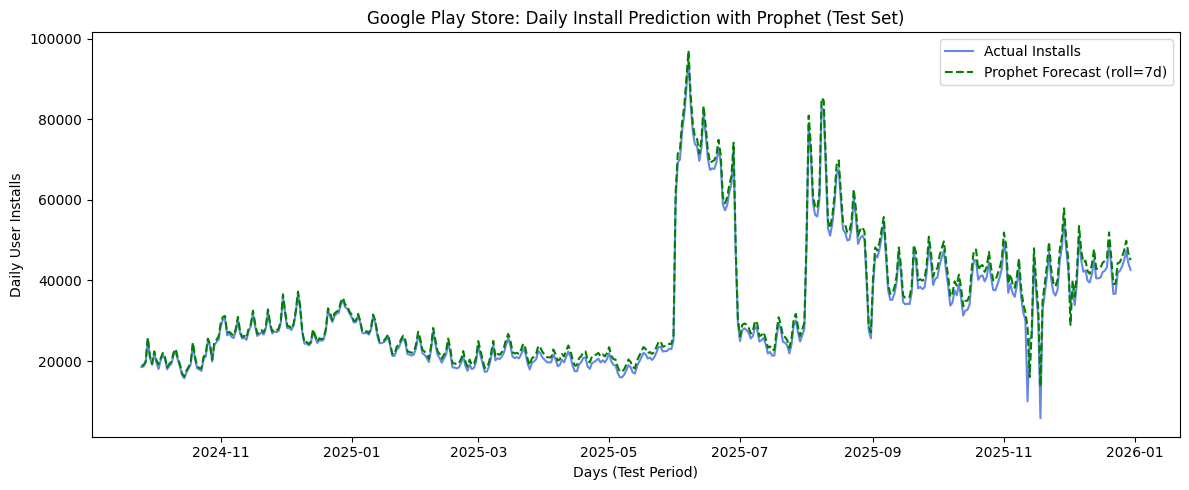

In [49]:
import random
import numpy as np
import pandas as pd
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# ── Hyperparameters ───────────────────────────────────────
SEED                    = 42
ROLL_PERIOD             = 7      # Rolling window size (change as needed)
TRAIN_RATIO             = 0.8    # Train/test split ratio
CHANGEPOINT_PRIOR_SCALE = 1.0    # Higher = more flexible trend
SEASONALITY_PRIOR_SCALE = 10     # Higher = stronger seasonality

DATA_CSV_FILE = "../../../data/ds_data_clean.csv"
# ─────────────────────────────────────────────────────────

random.seed(SEED)
np.random.seed(SEED)

# 1. Load Data
df = pd.read_csv(DATA_CSV_FILE)
df["Date"] = pd.to_datetime(df["Date"])
df["Is Weekend"] = (df["Date"].dt.dayofweek >= 5).astype(int)

# 2. Prepare for Prophet
prophet_df = df[[
    "Date", "Daily User Installs", "Daily Average Rating",
    "Daily Crashes", "Daily Device Installs", "Daily Device Uninstalls",
    "Daily User Uninstalls", "Active Device Installs", "Daily ANRs", "Is Weekend"
]].copy()

prophet_df.columns = [
    "ds", "y", "rating", "crashes", "device_installs",
    "device_uninstalls", "user_uninstalls", "active_installs", "anrs", "is_weekend"
]

print(f"Total days : {len(prophet_df)}")
print(f"Train size : {int(len(prophet_df) * TRAIN_RATIO)}")
print(f"Test size  : {len(prophet_df) - int(len(prophet_df) * TRAIN_RATIO)}")

# 3. Train/Test Split (by time, 80/20)
split_idx = int(len(prophet_df) * TRAIN_RATIO)
train = prophet_df.iloc[:split_idx]
test  = prophet_df.iloc[split_idx:].reset_index(drop=True)

print(f"Train: {train['ds'].min().date()} → {train['ds'].max().date()}")
print(f"Test:  {test['ds'].min().date()} → {test['ds'].max().date()}")

# 4. Initialize and Fit Model
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    changepoint_prior_scale=CHANGEPOINT_PRIOR_SCALE,
    seasonality_prior_scale=SEASONALITY_PRIOR_SCALE,
)
model.add_country_holidays(country_name="US")

regressors = ["rating", "crashes", "device_installs", "device_uninstalls",
              "user_uninstalls", "active_installs", "anrs", "is_weekend"]
for reg in regressors:
    model.add_regressor(reg)

model.fit(train)
print("Model trained successfully")

# 5. Rolling Forecast over test set
all_predictions = []
all_actuals     = []
all_dates       = []

for i in range(0, len(test) - ROLL_PERIOD + 1, ROLL_PERIOD):
    window = test.iloc[i:i + ROLL_PERIOD]
    if len(window) < ROLL_PERIOD:
        break
    future   = window[["ds"] + regressors].copy()
    forecast = model.predict(future)
    all_predictions.extend(forecast["yhat"].values)
    all_actuals.extend(window["y"].values)
    all_dates.extend(window["ds"].values)

all_predictions = np.array(all_predictions)
all_actuals     = np.array(all_actuals)

# Clip negatives — installs can't be negative
all_predictions = np.maximum(all_predictions, 0)

print(f"Rolling windows evaluated : {len(all_actuals) // ROLL_PERIOD}")
print(f"Total days evaluated      : {len(all_actuals)}")

# 6. Evaluation
prophet_rmse = np.sqrt(mean_squared_error(all_actuals, all_predictions))
prophet_mae  = mean_absolute_error(all_actuals, all_predictions)
prophet_mape = np.mean(np.abs((all_actuals - all_predictions) / (all_actuals + 1e-8))) * 100

print("-" * 30)
print("PROPHET EVALUATION RESULTS")
print("-" * 30)
print(f"RMSE: {prophet_rmse:.2f} installs")
print(f"MAE:  {prophet_mae:.2f} installs")
print(f"MAPE: {prophet_mape:.2f}%")
print("-" * 30)


# 9. Save model metadata
import json
prophet_checkpoint = {
    "features"               : regressors,
    "target_col"             : "Daily User Installs",
    "roll_period"            : ROLL_PERIOD,
    "train_ratio"            : TRAIN_RATIO,
    "changepoint_prior_scale": CHANGEPOINT_PRIOR_SCALE,
    "seasonality_prior_scale": SEASONALITY_PRIOR_SCALE,
    "seed"                   : SEED,
    "model_type"             : "Prophet",
    "mae"                    : prophet_mae,
    "rmse"                   : prophet_rmse,
    "mape"                   : prophet_mape,
}
with open("prophet_model_meta.json", "w") as f:
    json.dump(prophet_checkpoint, f, indent=2)

print("Model metadata saved to prophet_model_meta.json")


# 7. Full series plot
plt.figure(figsize=(14, 5))

# Full actual series
plt.plot(prophet_df["ds"], prophet_df["y"], 
         label="Actual Installs", color="royalblue", alpha=0.8)

# Overlay actual values in test period for comparison
plt.plot(all_dates, all_actuals, 
         label="Actual Installs (Test Period)", color="royalblue", alpha=0.8)

# Forecast
plt.plot(all_dates, all_predictions, 
         label=f"Prophet Forecast (roll={ROLL_PERIOD}d)", color="green", linestyle="--")

plt.axvline(x=train["ds"].max(), color="red", linestyle="--", label="Train/Test Split")
plt.title("Google Play Store: Daily Install Prediction with Prophet")
plt.xlabel("Date")
plt.ylabel("Daily User Installs")
plt.legend()
plt.tight_layout()
plt.savefig("prophet_forecast_plot.png")
plt.show()

plt.plot(all_dates, all_predictions, 
         label=f"Prophet Forecast (roll={ROLL_PERIOD}d)", 
         color="green", linestyle="--", linewidth=2)


# Error Distribution Plot
errors = all_actuals - all_predictions
plt.figure(figsize=(10, 5))
plt.hist(errors, bins=50, color="skyblue", edgecolor="black")
plt.axvline(0, color="red", linestyle="--")
plt.title("Distribution of Prediction Errors (Residuals)")
plt.xlabel("Error (Actual - Predicted)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("prophet_error_distribution.png")
plt.show()



# Test period zoomed plot
plt.figure(figsize=(12, 5))
plt.plot(all_dates, all_actuals,
         label="Actual Installs", color="royalblue", alpha=0.8)
plt.plot(all_dates, all_predictions,
         label=f"Prophet Forecast (roll={ROLL_PERIOD}d)", color="green", linestyle="--")
plt.title("Google Play Store: Daily Install Prediction with Prophet (Test Set)")
plt.xlabel("Days (Test Period)")
plt.ylabel("Daily User Installs")
plt.legend()
plt.tight_layout()
plt.savefig("prophet_test_forecast.png")
plt.show()